In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [7]:
plt.rcParams.update({'font.size': 12})

In [8]:

# Load the new CSV files
new_file_path_099 = '../hyperfine_results_0.99.csv'
new_file_path_075 = '../hyperfine_results_0.75.csv'

# Read the new files into pandas DataFrames
new_df_099 = pd.read_csv(new_file_path_099, header=None)
new_df_075 = pd.read_csv(new_file_path_075, header=None)

# Assign column names
column_names = ['dimensions', 'bit_level', 'test_type', 'mean_runtime_ms', 'stddev_ms']
new_df_099.columns = column_names
new_df_075.columns = column_names

# Add a column for delta values
new_df_099['delta'] = 0.99
new_df_075['delta'] = 0.75

# Combine the two new dataframes
new_combined_df = pd.concat([new_df_099, new_df_075])

# Creating a pivot table to reorganize the new data
new_pivot_df = new_combined_df.pivot_table(index='dimensions', columns='delta', values='mean_runtime_ms', aggfunc='mean')

# Resetting index to make 'dimensions' a column again
new_pivot_df.reset_index(inplace=True)

# Melting the dataframe to long format for seaborn plot
new_melted_df = new_pivot_df.melt(id_vars='dimensions', var_name='delta', value_name='mean_runtime_ms')

/var/folders/rr/ts5lchcx1rj93g0lycjm_dy80000gn/T/ipykernel_22847/2681197084.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(data=new_melted_df, x='dimensions', y='mean_runtime_ms', hue='delta', ci=None, palette="tab10")


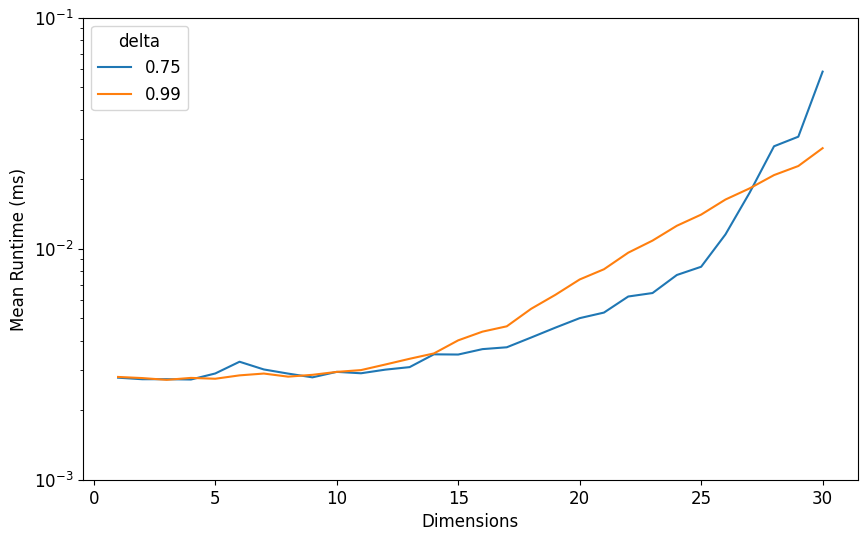

In [23]:
plt.figure(figsize=(10, 6))
sns.lineplot(data=new_melted_df, x='dimensions', y='mean_runtime_ms', hue='delta', ci=None, palette="tab10")
plt.yscale('log')
plt.xlabel('Dimensions')
plt.ylabel('Mean Runtime (ms)')

# Set custom y-axis limits
plt.ylim(0.002, 0.1)  # Replace ymin and ymax with your desired values

file_path_to_save = 'mean_runtime_vs_dimensions_plot.png'
plt.savefig(file_path_to_save, dpi=800)
plt.show()
